In [3]:
import numpy as np
from qutip import *
from scipy.linalg import sqrtm, eigvalsh
from scipy.stats import linregress
import numba
from numba import njit, prange
import pickle
import os
import time

## Fidelity
Generic definition : 
$$ \mathcal{F}\left( \rho, \sigma \right) = \left( Tr \left[ \sqrt{ \sqrt{\rho} \sigma \sqrt{\rho} }\right] \right)^{2} $$ 
Definition for $ \rho $ Pure State and $ \sigma $ Mixed State : 
$$ \mathcal{F}\left( \rho, \sigma \right) = \langle \psi_{\sigma} | \sigma | \psi_{\sigma} \rangle $$
Definition for Pure State : 
$$ \mathcal{F}\left( \rho, \sigma \right) = |\langle \psi_{\rho} | \psi_{\sigma} \rangle|^{2} $$
Definition for Qubits : 
$$ \mathcal{F}\left( \rho, \sigma \right) = Tr\left( \rho \, \sigma \right) + 2 \sqrt{Det\left ( \rho \right) \, Det\left ( \sigma \right)} $$
## Trace Distance
Generic definition : 
$$ \mathcal{T}\left( \rho, \sigma \right) = \frac{1}{2} Tr \left[ \sqrt{\left( \rho - \sigma \right)^{\dagger} \left( \rho - \sigma  \right)} \right] $$
### Relationship : Fuchs-van de Graaf inequality
$$ 1 - \sqrt{\mathcal{F}\left( \rho, \sigma \right)} \leq \mathcal{T}\left( \rho, \sigma \right) \leq \sqrt{1 - \mathcal{F}\left( \rho, \sigma \right)} $$

In [ ]:
def fidelity_generic(rho, sigma):
    """
    Calculate the quantum fidelity between two generic density matrices.
    Formula: F(rho, sigma) = ( Tr[ sqrt( sqrt(rho) * sigma * sqrt(rho) ) ] )^2
    
    This version avoids scipy.linalg.sqrtm to prevent RuntimeWarnings, 
    using stable eigenvalue decomposition instead.
    
    Parameters:
        rho (numpy.ndarray): First density matrix (NxN).
        sigma (numpy.ndarray): Second density matrix (NxN).
        
    Returns:
        float: The fidelity between rho and sigma (real number between 0 and 1).
    """
    # 1. Square root of rho using eigenvalue decomposition
    evals_rho, evecs_rho = np.linalg.eigh(rho)
    # Truncate any negative noise to 0.0 before taking the square root
    evals_rho = np.maximum(evals_rho, 0.0) 
    sqrt_rho = evecs_rho @ np.diag(np.sqrt(evals_rho)) @ evecs_rho.conj().T
    
    # 2. Inner matrix: sqrt(rho) * sigma * sqrt(rho)
    inner_matrix = sqrt_rho @ sigma @ sqrt_rho
    
    # Force exact Hermiticity to remove any small imaginary noise
    inner_matrix = 0.5 * (inner_matrix + inner_matrix.conj().T)
    
    # 3. Trace of the square root is the sum of the square roots of the eigenvalues
    evals_inner = eigvalsh(inner_matrix)
    # Again, truncate negative noise to 0.0 before square root
    evals_inner = np.maximum(evals_inner, 0.0)
    
    fidelity = np.sum(np.sqrt(evals_inner))**2
    
    # Ensure numerical errors do not push fidelity slightly above 1.0
    return min(1.0, fidelity)
    

In [ ]:
def fidelity_qubit(rho, sigma):
    """
    Calculate the exact quantum fidelity between two single-qubit (2x2) density matrices.
    Formula: F(rho, sigma) = Tr(rho * sigma) + 2 * sqrt(Det(rho) * Det(sigma))
    """
    # Trace of the matrix product
    tr_term = np.real(np.trace(rho @ sigma))
    
    # Determinants of the two density matrices
    det_rho = np.real(np.linalg.det(rho))
    det_sigma = np.real(np.linalg.det(sigma))
    
    # FIX NUMERICO: Tronchiamo a 0 gli eventuali valori negativi infinitesimi
    det_rho = max(0.0, det_rho)
    det_sigma = max(0.0, det_sigma)
    
    # Calculate fidelity using the analytical formula for qubits
    fidelity = tr_term + 2.0 * np.sqrt(det_rho * det_sigma)
    
    return fidelity

In [ ]:
def trace_distance_generic(rho, sigma):
    """
    Calculate the Trace Distance between two generic density matrices.
    Formula: T(rho, sigma) = 1/2 * Tr[ sqrt( (rho - sigma)^dagger * (rho - sigma) ) ]
    
    Parameters:
        rho (numpy.ndarray): First density matrix (NxN).
        sigma (numpy.ndarray): Second density matrix (NxN).
        
    Returns:
        float: The trace distance between rho and sigma (real number between 0 and 1).
    """
    # Difference between the matrices
    diff = rho - sigma
    
    # Force exact Hermiticity to remove numerical noise
    diff = 0.5 * (diff + diff.conj().T)
    
    # Calculate the eigenvalues of the strictly Hermitian matrix 'diff'
    eigenvalues = eigvalsh(diff)
    
    # Trace distance is half the sum of the absolute eigenvalues
    t_dist = 0.5 * np.sum(np.abs(eigenvalues))
    
    # Ensure it stays within physical bounds
    return min(1.0, t_dist)
    

In [ ]:
def trace_distance_qubit(rho, sigma):
    """
    Calculate the exact Trace Distance between two single-qubit (2x2) density matrices.
    For a 2x2 traceless Hermitian matrix (rho - sigma), Det(diff) = -lambda^2 <= 0.
    Therefore, the Trace Distance simplifies to sqrt(-Det(rho - sigma)).
    
    Parameters:
        rho (numpy.ndarray): First density matrix (2x2).
        sigma (numpy.ndarray): Second density matrix (2x2).
        
    Returns:
        float: The trace distance between rho and sigma.
    """
    # Difference between the matrices
    diff = rho - sigma
    
    # Determinant of the difference
    det_diff = np.real(np.linalg.det(diff))
    
    # Since det_diff should be <= 0, -det_diff should be >= 0.
    # We use max(0.0, ...) to truncate any negative noise before applying sqrt.
    val_under_sqrt = max(0.0, -det_diff)
    
    t_dist = np.sqrt(val_under_sqrt)
    
    return min(1.0, t_dist)
    

# Results Analysis

In [8]:
# ==========================
# Parametri Globali di Plot
# ==========================
results_dir = "../Results/Data/Complete_rho"
dt = 0.01

# ---> CAMBIA QUESTO VALORE PER SELEZIONARE IL FILE <---
theta_target_deg = 90.0  

# Conversione in radianti e formattazione stringa per trovare il file
theta_rad = np.radians(theta_target_deg)
theta_str = f"{theta_rad:.6f}".replace(".", "p")
dt_str = f"{dt:.6f}".replace(".", "p")

# Nome del file (assumendo N_traj = 20000 dal calcolo massivo)
filename = f"result_theta{theta_str}_dt{dt_str}_Ntraj20000.npz"
#filename = "result_theta0p000000_dt0p010000_Ntraj20000.npz"  # only for 0.0 deg
filepath = os.path.join(results_dir, filename)

print(f"Analisi impostata per theta = {theta_target_deg}°")
print(f"File target: {filename}")

Analisi impostata per theta = 90.0°
File target: result_theta1p570796_dt0p010000_Ntraj20000.npz


 ### Data Extraction

In [9]:
if not os.path.exists(filepath):
    print(f"ERRORE: Il file {filepath} non esiste. Controlla di aver completato la simulazione per questo angolo.")
else:
    # Caricamento del dizionario compresso
    data = np.load(filepath)
    
    times = data['times']
    n_times = len(times)
    
    print("Estrazione matrici in corso...")
    
    # ==========================================================
    # 1. Estrazione Lindblad (Riferimento Teorico)
    # ==========================================================
    rho_lindblad = data['rho_list_lindblad']
    # La Lindblad nel file completo è 4x4. 
    # Indice 2 -> stato |10>, Indice 1 -> stato |01>
    pop_lindblad_10 = np.real(rho_lindblad[:, 2, 2])
    pop_lindblad_01 = np.real(rho_lindblad[:, 1, 1])
    
    # Coerenze: ATTENZIONE sono invertite rispetto alle traiettorie, dunque le inverto
    # (2, 1) è l'elemento in basso a sinistra -> |10><01|
    cohe_lindblad_10_01 = rho_lindblad[:, 1, 2] 
    # (1, 2) è l'elemento in alto a destra -> |01><10|
    cohe_lindblad_01_10 = rho_lindblad[:, 2, 1]
    
    # ==========================================================
    # 2. Estrazione Matrici Traiettorie Raw (tutte le N colonne)
    # FIX: Incrocio delle chiavi per allineare gli elementi fuori diagonale
    # ==========================================================
    # I file raw salvano l'elemento (0,0) della sottomatrice come pop_00 
    # e l'elemento (1,1) come pop_11.
    pop_traj_10 = data['pop_00']
    pop_traj_01 = data['pop_11']
    
    # L'elemento (0,1) della sottomatrice (in alto a destra) corrisponde a |10><01|.
    # Nel file è stato salvato sotto la chiave 'coh_01_10'. Lo incrociamo:
    cohe_traj_10_01 = data['coh_10_01'] 
    
    # L'elemento (1,0) della sottomatrice (in basso a sinistra) corrisponde a |01><10|.
    # Nel file è stato salvato sotto la chiave 'coh_10_01'. Lo incrociamo:
    cohe_traj_01_10 = data['coh_01_10']

    print("Dati estratti e allineati con successo!")

Estrazione matrici in corso...
Dati estratti e allineati con successo!


In [8]:
cohe_lindblad_01_10

array([-2.06562840e-17+1.53153075e-19j, -1.11749149e-05-9.99532592e-03j,
       -4.46653464e-05-1.99766138e-02j, ...,
        3.45478063e-04-2.51093441e-04j,  3.44501022e-04-3.14095007e-04j,
        3.43384344e-04-3.76905661e-04j], shape=(10000,))

In [9]:
cohe_lindblad_10_01

array([ 1.81625040e-17+0.j        , -1.11749149e-05+0.00999533j,
       -4.46653464e-05+0.01997661j, ...,  3.45478063e-04+0.00025109j,
        3.44501022e-04+0.0003141j ,  3.43384344e-04+0.00037691j],
      shape=(10000,))

In [10]:
cohe_traj_10_01_mean = np.mean(cohe_traj_10_01, axis=1)
cohe_traj_10_01_mean

array([ 0.00000000e+00+0.j        , -1.11723055e-05+0.00999233j,
       -4.46343909e-05+0.01996161j, ...,  1.82455318e-03+0.00173324j,
        1.80062035e-03+0.0017469j ,  1.82126653e-03+0.00200584j],
      shape=(10000,))

In [11]:
cohe_traj_01_10_mean = np.mean(cohe_traj_01_10, axis=1)
cohe_traj_01_10_mean

array([ 0.00000000e+00+0.j        , -1.11723055e-05-0.00999233j,
       -4.46343909e-05-0.01996161j, ...,  1.82455318e-03-0.00173324j,
        1.80062035e-03-0.0017469j ,  1.82126653e-03-0.00200584j],
      shape=(10000,))

In [12]:
diff = cohe_lindblad_10_01 - cohe_traj_10_01_mean
diff

array([ 1.81625040e-17+0.00000000e+00j, -2.60949202e-09+3.00043120e-06j,
       -3.09555195e-08+1.50044150e-05j, ...,
       -1.47907512e-03-1.48214446e-03j, -1.45611933e-03-1.43280483e-03j,
       -1.47788219e-03-1.62893320e-03j], shape=(10000,))

In [13]:
pop_traj_10_mean = np.mean(pop_traj_10, axis=1)
pop_traj_01_mean = np.mean(pop_traj_01, axis=1)

## Purity

$ P = Tr[\rho^2]  $

In [14]:
import numpy as np
import time

print("Inizio il controllo di purezza su tutte le traiettorie e tutti i tempi...")
start_time = time.time()

n_times, N_traj_tot = pop_traj_10.shape
max_deviation = 0.0

# Usiamo il chunking per analizzare i dati a blocchi di 5000 traiettorie alla volta, usando RAM quasi nulla
CHUNK_SIZE = 5000
n_chunks = int(np.ceil(N_traj_tot / CHUNK_SIZE))

for i in range(n_chunks):
    start_idx = i * CHUNK_SIZE
    end_idx = min((i + 1) * CHUNK_SIZE, N_traj_tot)
    
    # 1. Estraiamo il blocco corrente
    p10_chunk = pop_traj_10[:, start_idx:end_idx]
    p01_chunk = pop_traj_01[:, start_idx:end_idx]
    c_chunk = cohe_traj_10_01[:, start_idx:end_idx]
    
    # 2. Calcoliamo la purezza: p10^2 + p01^2 + 2*|c|^2
    # Essendo tutte quantità reali (le popolazioni lo sono per definizione, e il modulo quadro anche),
    # il risultato sarà strettamente reale.
    purity_chunk = p10_chunk**2 + p01_chunk**2 + 2 * (np.abs(c_chunk)**2)
    
    # 3. Troviamo la deviazione massima assoluta dal valore teorico 1.0
    chunk_max_dev = np.max(np.abs(1.0 - purity_chunk))
    
    if chunk_max_dev > max_deviation:
        max_deviation = chunk_max_dev

print(f"Controllo completato in {time.time() - start_time:.4f} secondi.")
print(f"Deviazione massima dalla purezza ideale (1.0): {max_deviation:.4e}")

# Valutazione automatica del risultato
if max_deviation < 1e-10:
    print("\n✅ TEST SUPERATO: Tutte le traiettorie mantengono uno stato perfettamente puro!")
else:
    print("\n⚠️ ATTENZIONE: Trovata una deviazione significativa dalla purezza. Controlla la normalizzazione nel simulatore.")

Inizio il controllo di purezza su tutte le traiettorie e tutti i tempi...
Controllo completato in 14.7976 secondi.
Deviazione massima dalla purezza ideale (1.0): 1.3323e-15

✅ TEST SUPERATO: Tutte le traiettorie mantengono uno stato perfettamente puro!


## Fidelity calculation

In [23]:
# ==============================================================
# CALCOLO FIDELITY - ZERO-RAM, ON-THE-FLY
# Formula corretta per stato puro vs misto: F = Tr(rho * sigma)
# Nessuna fidelity_matrix allocata: heatmap costruita direttamente
# ==============================================================
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

print("Inizio calcolo Fidelity on-the-fly (Zero-RAM)...")
start_time = time.time()

n_times, N_traj_tot = pop_traj_10.shape
N_traj_plot = N_traj_tot

# Prepariamo la heatmap direttamente in float32 (dimezza la RAM vs float64)
fid_bins = 150
fid_edges = np.linspace(0.0, 1.0, fid_bins + 1)
heatmap_image = np.zeros((fid_bins, n_times), dtype=np.float32)

for t in range(n_times):
    P00_t  = pop_traj_10[t, :N_traj_plot]
    P11_t  = pop_traj_01[t, :N_traj_plot]
    C10_t  = cohe_traj_10_01[t, :N_traj_plot]
    C01_t  = cohe_traj_01_10[t, :N_traj_plot]

    P00_L  = pop_lindblad_10[t]
    P11_L  = pop_lindblad_01[t]
    C10_L  = cohe_lindblad_10_01[t]  
    C01_L  = cohe_lindblad_01_10[t]   

    # Tr(rho_traj * rho_L): coerenze incrociate
    fid_t = np.real(
            P00_t * P00_L +
            C01_t * C10_L +   # C01_traj * C10_Lind
            C10_t * C01_L +   # C10_traj * C01_Lind
            P11_t * P11_L)

    counts, _ = np.histogram(fid_t, bins=fid_edges)
    heatmap_image[:, t] = counts / N_traj_plot

print(f"Calcolo completato in {time.time() - start_time:.4f} secondi!")
print(f"RAM heatmap: {heatmap_image.nbytes / 1e6:.1f} MB  "
      f"(vs ~{n_times * N_traj_tot * 8 / 1e6:.0f} MB della vecchia fidelity_matrix)")


Inizio calcolo Fidelity on-the-fly (Zero-RAM)...
Calcolo completato in 4.9626 secondi!
RAM heatmap: 6.0 MB  (vs ~1600 MB della vecchia fidelity_matrix)


### Plot 

In [16]:
%matplotlib ipympl
import matplotlib.pyplot as plt
from IPython.display import Image, display, Math

In [17]:
dt = 0.01

# ---> CAMBIA QUESTO VALORE PER SELEZIONARE IL FILE <---
theta_target_deg = 90.0 

site_index = 0 # change site '0' for |10>, '1' for |01>
N_traj = 20000 # change number of trajectories
theta_value = np.radians(theta_target_deg)

plt.close('all')

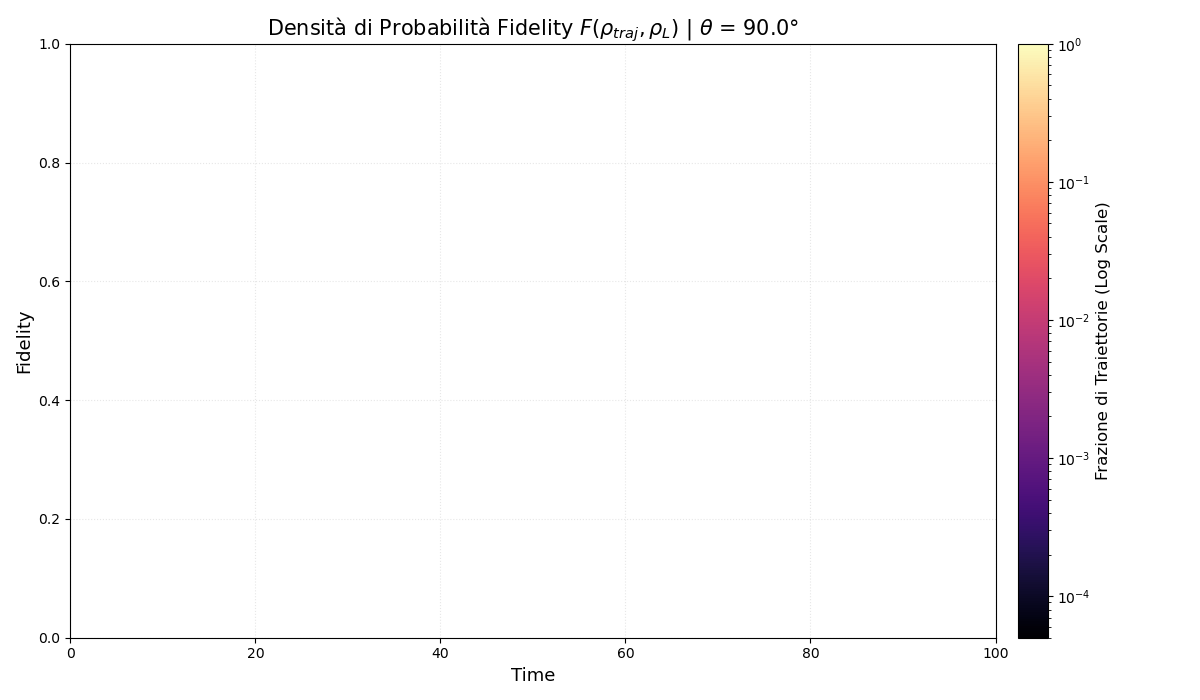

In [21]:
# ==============================================================
# PLOT HEATMAP FIDELITY
# ==============================================================
fig, ax = plt.subplots(figsize=(12, 7))

heatmap_masked = np.ma.masked_where(heatmap_image == 0, heatmap_image)
vmin_val = 1.0 / N_traj_plot

image = ax.imshow(
    heatmap_masked,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], 0.0, 1.0],
    cmap='magma',
    norm=LogNorm(vmin=vmin_val, vmax=1.0)
)

cbar = fig.colorbar(image, ax=ax, pad=0.02)
cbar.set_label('Frazione di Traiettorie (Log Scale)', fontsize=12)

ax.set_title(f"Densità di Probabilità Fidelity $F(\\rho_{{traj}}, \\rho_{{L}})$ | $\\theta$ = {theta_target_deg}°", fontsize=15)
ax.set_xlabel("Time", fontsize=13)
ax.set_ylabel("Fidelity", fontsize=13)
ax.grid(alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()


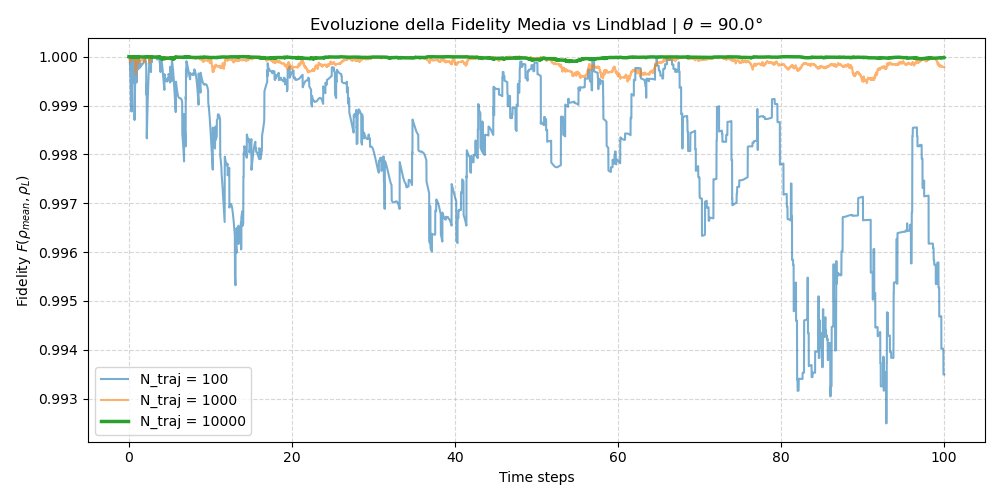

In [28]:
# ==============================================================
# Fidelity della MEDIA per N traiettorie 
# ==============================================================
N_list = [100, 1000, 10000]

plt.figure(figsize=(10, 5))

for N in N_list:
    # Medie delle 4 componenti su N traiettorie (shape: n_times)
    pop_10_m   = np.mean(pop_traj_10[:,    :N], axis=1)
    pop_01_m   = np.mean(pop_traj_01[:,    :N], axis=1)
    coh_1001_m = np.mean(cohe_traj_10_01[:, :N], axis=1)
    coh_0110_m = np.mean(cohe_traj_01_10[:, :N], axis=1)

    rho_list_avg = np.zeros((n_times, 2, 2), dtype=np.complex128)
    for t in range(n_times) : 
        rho_list_avg[t] = [[pop_10_m[t], coh_1001_m[t]],[coh_0110_m[t], pop_01_m[t]]]

    rho_list_lindblad= np.zeros((n_times, 2, 2), dtype=np.complex128)
    for t in range(n_times) : 
        rho_list_lindblad[t] = [[pop_lindblad_10[t], cohe_lindblad_10_01[t]],[cohe_lindblad_01_10[t], pop_lindblad_01[t]]]

    fidelity_list = np.zeros((n_times), dtype=np.float32)
    for t in range(n_times) : 
        fidelity_list[t] = fidelity_qubit(rho_list_avg[t], rho_list_lindblad[t])

    alpha_val = 0.6 if N < 10000 else 1.0
    lw = 1.5 if N < 10000 else 2.5
    plt.plot(times, fidelity_list, label=f'N_traj = {N}', alpha=alpha_val, linewidth=lw)

plt.xlabel("Time steps")
plt.ylabel("Fidelity $F(\\rho_{mean}, \\rho_L)$")
plt.title(f"Evoluzione della Fidelity Media vs Lindblad | $\\theta$ = {theta_target_deg}°")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Trace Distance calculation

In [20]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

print("Inizio calcolo Trace Distance on-the-fly (Zero-RAM)...")
start_time = time.time()

# 1. Prepariamo l'immagine vuota e i bins (da 0 a 1)
td_bins = 150
td_edges = np.linspace(0.0, 1.0, td_bins + 1)
heatmap_image_td = np.zeros((td_bins, n_times))

# 2. Ciclo sul tempo: estraiamo solo la riga corrente, calcoliamo e facciamo l'istogramma
for t in range(n_times):
    # Estraiamo i dati di tutte le N_traj ma SOLO per l'istante t (pesa pochissimi Kilobyte!)
    p10_t = pop_traj_10[t, :N_traj]
    p01_t = pop_traj_01[t, :N_traj]
    c10_01_t = cohe_traj_10_01[t, :N_traj]
    c01_10_t = cohe_traj_01_10[t, :N_traj]
    
    # Lindblad al tempo t (sono singoli numeri)
    L10_t = pop_lindblad_10[t]
    L01_t = pop_lindblad_01[t]
    L10_01_t = cohe_lindblad_10_01[t]
    L01_10_t = cohe_lindblad_01_10[t]
    
    # Calcoliamo la differenza vettorizzata solo per l'istante t
    D_10 = p10_t - L10_t
    D_01 = p01_t - L01_t
    D_10_01 = c10_01_t - L10_01_t
    D_01_10 = c01_10_t - L01_10_t
    
    # Determinante e Trace Distance per l'istante t
    det_diff = np.real(D_10 * D_01 - D_10_01 * D_01_10)
    td_t = np.sqrt(np.maximum(0.0, -det_diff))
    
    # Generiamo l'istogramma della colonna e normalizziamo
    counts, _ = np.histogram(td_t, bins=td_edges)
    heatmap_image_td[:, t] = counts / N_traj

print(f"Calcolo e generazione mappa completati in {time.time() - start_time:.4f} secondi!")

Inizio calcolo Trace Distance on-the-fly (Zero-RAM)...
Calcolo e generazione mappa completati in 5.9525 secondi!


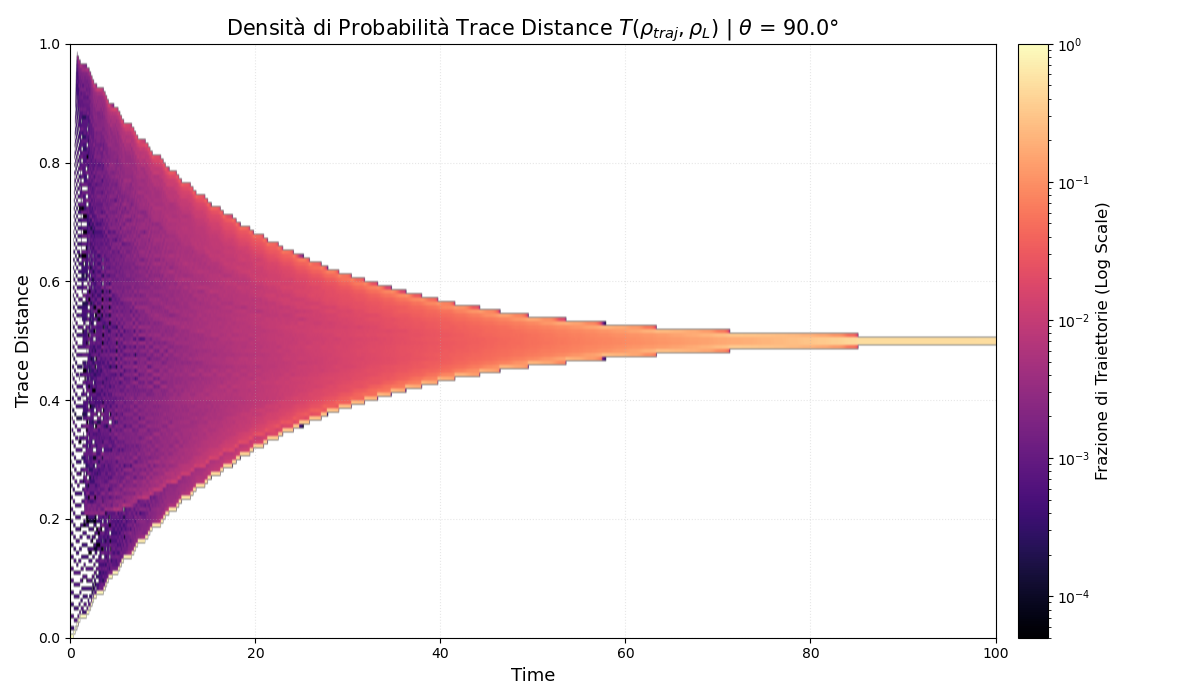

In [21]:
# ==========================================================
# PLOT HEATMAP TRACE DISTANCE
# ==========================================================
fig, ax = plt.subplots(figsize=(12, 7))

# Maschera per le zone senza traiettorie (restano bianche)
heatmap_masked_td = np.ma.masked_where(heatmap_image_td == 0, heatmap_image_td)

vmin_val = 1.0 / N_traj
image_td = ax.imshow(
    heatmap_masked_td, 
    aspect='auto', 
    origin='lower', 
    extent=[times[0], times[-1], 0.0, 1.0], 
    cmap='magma',
    norm=LogNorm(vmin=vmin_val, vmax=1.0) 
)

cbar = fig.colorbar(image_td, ax=ax, pad=0.02)
cbar.set_label('Frazione di Traiettorie (Log Scale)', fontsize=12)

ax.set_title(f"Densità di Probabilità Trace Distance $T(\\rho_{{traj}}, \\rho_{{L}})$ | $\\theta$ = {theta_target_deg}°", fontsize=15)
ax.set_xlabel("Time", fontsize=13)
ax.set_ylabel("Trace Distance", fontsize=13)
ax.grid(alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

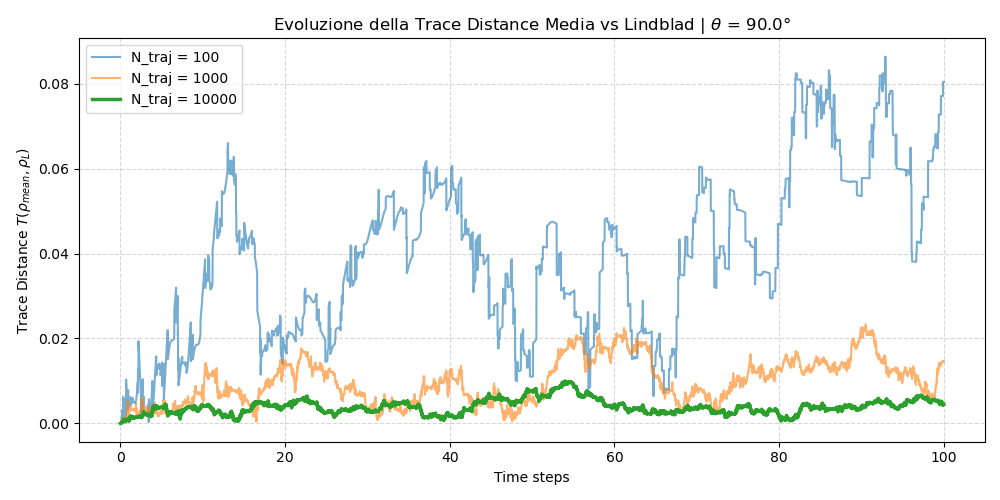

In [22]:
# ==========================================================
# Calcolo della Trace Distance della Media per N traiettorie
# ==========================================================

N_list = [100, 1000, 10000]

plt.figure(figsize=(10, 5))

for N in N_list:
    # 1. Calcolo rapido delle popolazioni e coerenze medie per N traiettorie
    pop_10_m = np.mean(pop_traj_10[:, :N], axis=1)
    pop_01_m = np.mean(pop_traj_01[:, :N], axis=1)
    cohe_10_01_m = np.mean(cohe_traj_10_01[:, :N], axis=1)
    cohe_01_10_m = np.mean(cohe_traj_01_10[:, :N], axis=1)
    
    # 2. Differenza vettorizzata con Lindblad
    D_10_m = pop_10_m - pop_lindblad_10
    D_01_m = pop_01_m - pop_lindblad_01
    D_10_01_m = cohe_10_01_m - cohe_lindblad_10_01
    D_01_10_m = cohe_01_10_m - cohe_lindblad_01_10
    
    # 3. Determinante della differenza
    det_diff_m = np.real(D_10_m * D_01_m - D_10_01_m * D_01_10_m)
    
    # 4. Trace Distance = sqrt(-Det)
    val_under_sqrt_m = np.maximum(0.0, -det_diff_m)
    td_mean_array = np.sqrt(val_under_sqrt_m)
    
    # Stile dinamico: la curva a 10000 sarà la più marcata
    alpha_val = 0.6 if N < 10000 else 1.0
    lw = 1.5 if N < 10000 else 2.5
    
    plt.plot(times, td_mean_array, label=f'N_traj = {N}', alpha=alpha_val, linewidth=lw)

# Abbellimenti
plt.xlabel("Time steps")
plt.ylabel("Trace Distance $T(\\rho_{mean}, \\rho_L)$")
plt.title(f"Evoluzione della Trace Distance Media vs Lindblad | $\\theta$ = {theta_target_deg}°")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Fissiamo l'asse Y per far risaltare quanto ci avviciniamo allo zero
# Modificalo se vedi che la curva per 100 "buca" il tetto di 0.1
#plt.ylim(-0.005, 0.1)

plt.tight_layout()
plt.show()

In [52]:
# =============================================================================
# Calcolo andamento nel tempo della Fidelity tra Singola Traiettoria e Lindbald 
# =============================================================================

index = 10

rho_list_single_traj = np.zeros((n_times, 2, 2), dtype=np.complex128)
for t in range(n_times) : 
    rho_list_single_traj[t] = [[pop_traj_10[t, index], cohe_traj_10_01[t, index]],[cohe_traj_01_10[t, index], pop_traj_01[t, index]]]

rho_list_lindblad= np.zeros((n_times, 2, 2), dtype=np.complex128)
for t in range(n_times) : 
    rho_list_lindblad[t] = [[pop_lindblad_10[t], cohe_lindblad_10_01[t]],[cohe_lindblad_01_10[t], pop_lindblad_01[t]]]


fidelity_list = np.zeros((n_times), dtype=np.float32)
for t in range(n_times) : 
    fidelity_list[t] = fidelity_qubit(rho_list_single_traj[t], rho_list_lindblad[t])
    

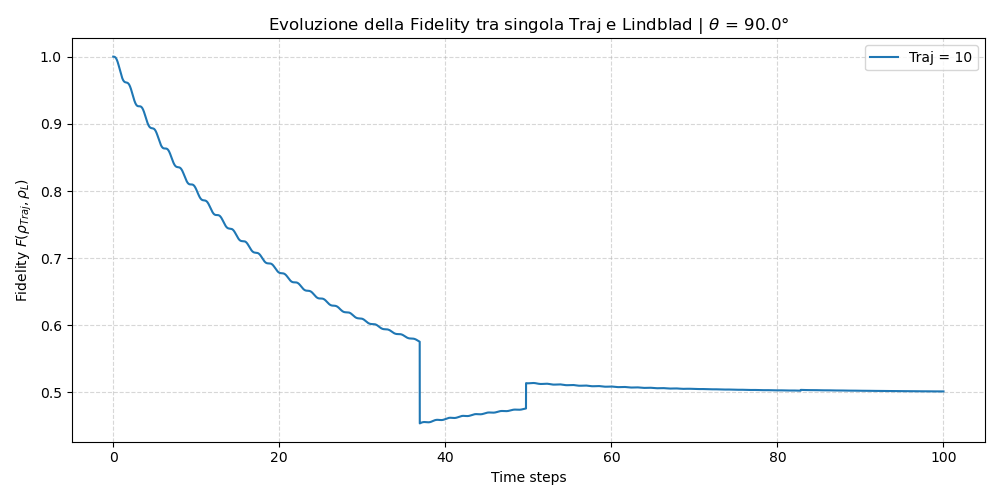

In [53]:
fig05, ax = plt.subplots(figsize=(10, 5)) 

ax.plot(times, fidelity_list, label=f"Traj = {index}")

ax.set_xlabel("Time steps")
ax.set_ylabel("Fidelity $F(\\rho_{Traj}, \\rho_L)$")
ax.set_title(f"Evoluzione della Fidelity tra singola Traj e Lindblad | $\\theta$ = {theta_target_deg}°")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# ======================================================================================================
# Calcolo andamento nel tempo della Fidelity tra Singola Traiettoria e Lindbald per tutte le traiettorie
# ======================================================================================================

# all_fidelity_list = np.zeros((n_times, N_traj),  dtype=float )
# for index in range(N_traj):
#     rho_list_single_traj = np.zeros((n_times, 2, 2), dtype=np.complex128)
#     rho_list_lindblad= np.zeros((n_times, 2, 2), dtype=np.complex128)
#     fidelity_list = np.zeros((n_times), dtype=np.float32)
    
#     for t in range(n_times) : 
#         rho_list_single_traj[t] = [[pop_traj_10[t, index], cohe_traj_10_01[t, index]],[cohe_traj_01_10[t, index], pop_traj_01[t, index]]]
    
    
#     #for t in range(n_times) : 
#         rho_list_lindblad[t] = [[pop_lindblad_10[t], cohe_lindblad_10_01[t]],[cohe_lindblad_01_10[t], pop_lindblad_01[t]]]
    
#     #for t in range(n_times) : 
#         #fidelity_list[t] = fidelity_qubit(rho_list_single_traj[t], rho_list_lindblad[t])
#         all_fidelity_list[t, index] = fidelity_qubit(rho_list_single_traj[t], rho_list_lindblad[t])
        

In [10]:
all_fidelity_list = np.zeros((n_times, N_traj),  dtype=float )


rho_list_lindblad= np.zeros((n_times, 2, 2), dtype=np.complex128)

for t in range(n_times) :
    rho_list_lindblad[t] = [[pop_lindblad_10[t], cohe_lindblad_10_01[t]],[cohe_lindblad_01_10[t], pop_lindblad_01[t]]]

for index in range(N_traj):
    rho_list_single_traj = np.zeros((n_times, 2, 2), dtype=np.complex128)
    
    fidelity_list = np.zeros((n_times), dtype=np.float32)
    
    for t in range(n_times) : 
        rho_list_single_traj[t] = [[pop_traj_10[t, index], cohe_traj_10_01[t, index]],[cohe_traj_01_10[t, index], pop_traj_01[t, index]]]
    
        all_fidelity_list[t, index] = fidelity_qubit(rho_list_single_traj[t], rho_list_lindblad[t])
        

KeyboardInterrupt: 

In [1]:
dt = 0.01

# ---> CAMBIA QUESTO VALORE PER SELEZIONARE IL FILE <---
theta_target_deg = 90.0 

site_index = 0 # change site '0' for |10>, '1' for |01>
N_traj = 20000 # change number of trajectories
theta_value = np.radians(theta_target_deg)

#plt.close('all')

NameError: name 'np' is not defined

In [ ]:
counts, _ = np.histogram(all_fidelity_list, bins=fid_edges)
heatmap_image[:, t] = counts / N_traj_plot

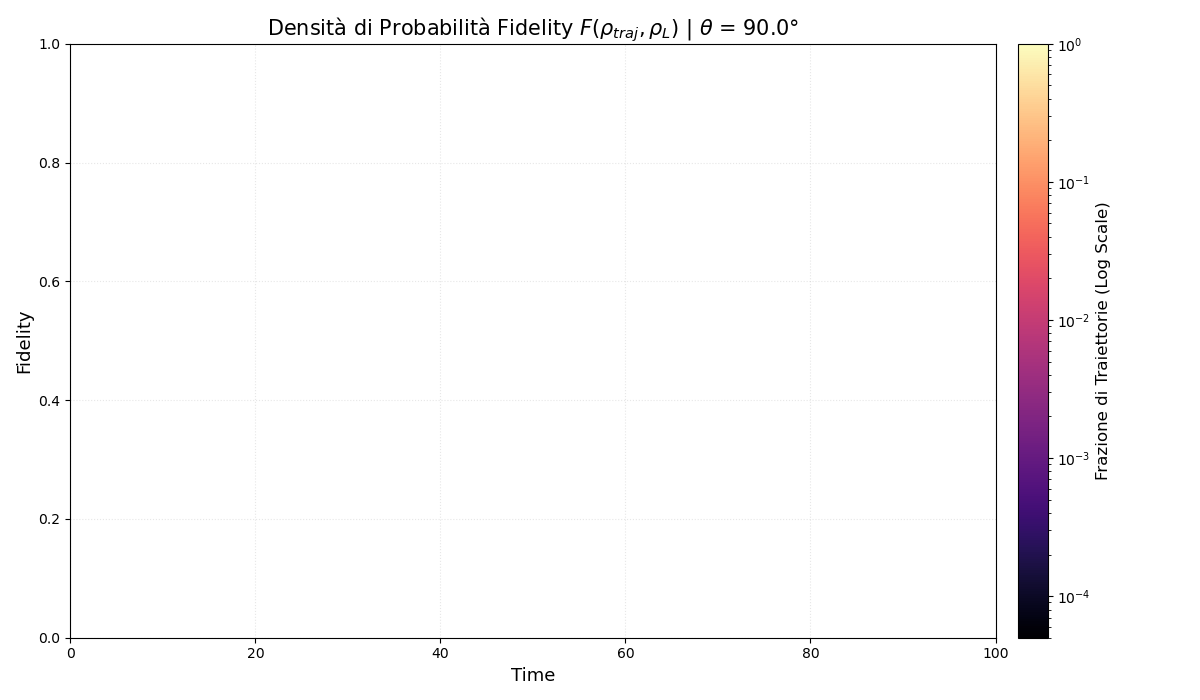

In [21]:
# ==============================================================
# PLOT HEATMAP FIDELITY
# ==============================================================
fig, ax = plt.subplots(figsize=(12, 7))

heatmap_masked = np.ma.masked_where(heatmap_image == 0, heatmap_image)
vmin_val = 1.0 / N_traj_plot

image = ax.imshow(
    heatmap_masked,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], 0.0, 1.0],
    cmap='magma',
    norm=LogNorm(vmin=vmin_val, vmax=1.0)
)

cbar = fig.colorbar(image, ax=ax, pad=0.02)
cbar.set_label('Frazione di Traiettorie (Log Scale)', fontsize=12)

ax.set_title(f"Densità di Probabilità Fidelity $F(\\rho_{{traj}}, \\rho_{{L}})$ | $\\theta$ = {theta_target_deg}°", fontsize=15)
ax.set_xlabel("Time", fontsize=13)
ax.set_ylabel("Fidelity", fontsize=13)
ax.grid(alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()
